In [1]:
import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy import integrate
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
import pickle # for saving simulations
import gzip
%matplotlib widget

In [2]:
parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
spme = pybamm.lithium_ion.SPMe()

In [3]:
file_path='Z:\\voltaiq_data\\Processed\\GMJuly2022\\GMJuly2022_CELL081\\RPT.pkl.gz'

with gzip.open(file_path, "rb") as f:
    hppc_data_raw = pickle.load(f)

hppc_data_raw = hppc_data_raw.sort_values(by=['Time [s]'])
hppc_data_raw = hppc_data_raw.reset_index(drop=True)
# hppc_data_raw

In [4]:
hppc_data_pulse = hppc_data_raw.iloc[9].Data #HPPC
hppc_data_charge = hppc_data_raw.iloc[10].Data #C/20 Discharge
hppc_data_discharge = hppc_data_raw.iloc[11].Data #C/20 Discharge
hppc_data=hppc_data_discharge

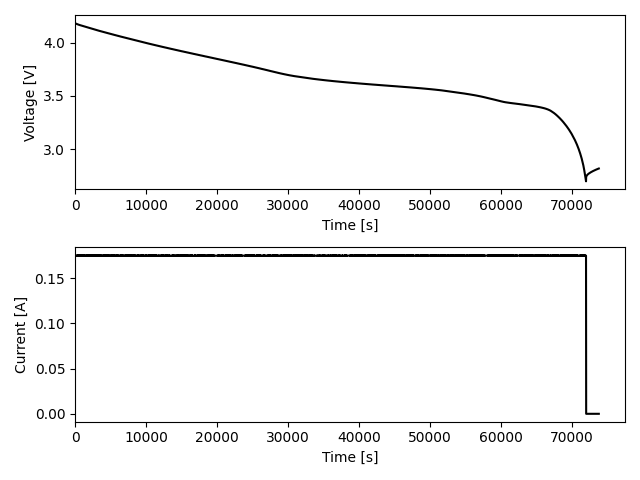

In [5]:
# hppc_data['Time [s]'] = hppc_data_raw['Time [s]'].str.replace(r'-05:00', '', regex=True)
#hppc_data['Time [s]'] = pd.to_datetime(hppc_data['Time [s]'] , format='%Y-%m-%d %H:%M:%S-%f:00')
data_time = hppc_data["Time [s]"].to_numpy()/1000# convert from unix time in ms?-hppc_data.iloc(0)["Time [s]"]
data_time=data_time-data_time[0]
# #data_time = data_time.values/1e9
# #data_time = data_time.astype('float')
data_current = hppc_data['Current [A]'].to_numpy()
# #data_current = data_current.values
#t_sim = np.arange(0,data_time[-1],0.1)
t_sim = np.arange(0,data_time[-1],10)

data_current = np.interp(t_sim, data_time, data_current, left=None, right=None, period=None)
data_voltage= hppc_data['Voltage [V]'].to_numpy()
# #data_voltage = data_voltage.values
data_voltage = np.interp(t_sim, data_time, data_voltage, left=None, right=None, period=None)

fig,ax = plt.subplots(2,1)
ax1 = ax.flat[0]
ax1.plot(t_sim,data_voltage,'k')
#ax1.plot(t,Vt,'r--')
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_sim,-data_current,'k')
#ax2.plot(t,I,'r--')
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
fig.tight_layout()


In [6]:
timescale = parameter_values.evaluate(spme.timescale)
# discharge is positive current in PyBaMM
current_interpolant = pybamm.Interpolant(
  #  drive_cycle[:, 0], drive_cycle[:, 1], timescale * pybamm.t
  t_sim, -data_current, timescale * pybamm.t
)
parameter_values["Current function [A]"] = current_interpolant

In [15]:
spme = pybamm.lithium_ion.SPMe()
param = spme.param
parameter_values.update(
    {
        "Maximum concentration in positive electrode [mol.m-3]":	31927.3,
        "Maximum concentration in negative electrode [mol.m-3]":	29637,
        "Upper voltage cut-off [V]": 4.2, 
        "Lower voltage cut-off [V]": 2.7, 
        },
    check_already_exists=False,
)    
parameter_values.search("maximum concentration")
parameter_values.search("voltage")
# Cn
C_n_init = 4.06
# Cp
C_p_init =5.5# 4.728
# x0 or x100 depending on starting at 0 SOC or 1 SOC
x_init = 0.852
# y0 or y100 depending on starting at 0 SOC or 1 SOC
y_init = 0.309

eps_n_init = parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
eps_p_init = parameter_values.evaluate(C_p_init*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
cs_n_init = parameter_values.evaluate(x_init* param.n.prim.c_max)
cs_p_init = parameter_values.evaluate(y_init* param.p.prim.c_max)

# Updating parameters for initialization
parameter_values.update(
    {
        "Negative electrode active material volume fraction": eps_n_init,
        "Positive electrode active material volume fraction": eps_p_init,
        "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
        "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
        "Initial temperature [K]": 273.15+25,
        "Ambient temperature [K]": 273.15+25,
    },
    check_already_exists=False,
)

Vmin = 2.7
Vmax = 4.2
esoh_model = pybamm.lithium_ion.ElectrodeSOH()
esoh_sim = pybamm.Simulation(esoh_model, parameter_values=parameter_values)
esoh_solver = pybamm.lithium_ion.ElectrodeSOHSolver(parameter_values, param)
Cn = parameter_values.evaluate(param.n.cap_init)
Cp = parameter_values.evaluate(param.p.cap_init)
eps_n = parameter_values["Negative electrode active material volume fraction"]
eps_p = parameter_values["Positive electrode active material volume fraction"]
c_n_max = parameter_values.evaluate(param.n.prim.c_max)
c_p_max = parameter_values.evaluate(param.p.prim.c_max)
n_Li_init = parameter_values.evaluate(param.n_Li_particles_init)

esoh_sol = esoh_sim.solve(
    [0],
    inputs={"V_min": Vmin, "V_max": Vmax, "C_n": Cn, "C_p": Cp, "n_Li": n_Li_init},
    solver=pybamm.AlgebraicSolver(),
)

x100=round(esoh_sol["x_100"].data[0],4)
y100=round(esoh_sol["y_100"].data[0],4)
x0=round(esoh_sol["x_0"].data[0],4)
y0=round(esoh_sol["y_0"].data[0],4)
Cn = round(Cn,4)
Cp = round(Cp,4)
print(f"x0: {x0}") 
print(f"x100: {x100}") 
print(f"y0: {y0}") 
print(f"y100: {y100}") 
print(f"Cn (usable): {(x100-x0)*Cn}") 
print(f"Cp (usable): {(y0-y100)*Cp}") 


Maximum concentration in negative electrode [mol.m-3]	29637
Maximum concentration in positive electrode [mol.m-3]	31927.3
Lower voltage cut-off [V]	2.7
Upper voltage cut-off [V]	4.2
x0: 0.0016
x100: 0.8525
y0: 0.9368
y100: 0.3086
Cn (usable): 3.4546539999999997
Cp (usable): 3.4551


In [16]:
sim_0 = pybamm.Simulation(spme, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol_0 = sim_0.solve(t_eval=t_sim) #,initial_soc =0.99



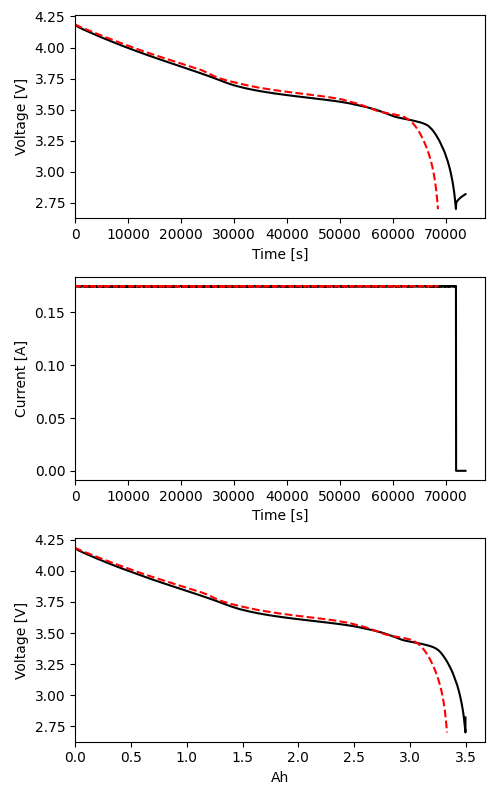

In [17]:
t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
Q = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries
Ah_sim=integrate.cumtrapz(I,t,initial=0)/3600
Ah_data=integrate.cumtrapz(-data_current,t_sim,initial=0)/3600

fig,ax = plt.subplots(3,1,figsize=(5,8))
ax1 = ax.flat[0]
ax1.plot(t_sim,data_voltage,'k')
ax1.plot(t,Vt,'r--')
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_sim,-data_current,'k')
ax2.plot(t,I,'r--')
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
ax3 = ax.flat[2]
ax3.plot(Ah_data,data_voltage,'k')
         
ax3.plot(Ah_sim,Vt,'r--')
ax3.set_xlim(left=0)
ax3.set_xlabel('Ah')
ax3.set_ylabel('Voltage [V]')
fig.tight_layout()